### Contents
1 Import libraries and dataset  
2 Correlation heatmap  
3 Scatterplots  
4 Pair plot  
5 Categorical plot  
6 Revisiting questions from last task  
7 Hypotheses

### 1 Import libraries and dataset

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

In [3]:
# Change set-up so that charts automatically display
%matplotlib inline

In [4]:
# Define path
path = r"C:\Users\cathe\OneDrive\Data Analysis\2 6 Schools in England and Wales"

In [5]:
# Import data
df = pd.read_csv(os.path.join(path, "02 Data", "Prepared Data", "complete_data_v2.csv"), index_col=False)

In [6]:
df.sample(5)

,Unnamed: 0,URN,Ofsted phase,School open date,Admissions policy,Sixth form,Region,Local authority,Postcode,IDACI quintile,...,Previous QE,Previous BA,Previous PD,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
7334,7334,139562,Primary,02/09/2013,Not applicable,Does not have a sixth form,London,Barnet,N20 0LP,1.0,...,9.0,9.0,9.0,2.0,395007,19240,35909,37069,92218,4488.7
9056,9056,143271,Primary,01/11/2016,Not applicable,Does not have a sixth form,North East,Newcastle upon Tyne,NE5 4EB,5.0,...,9.0,9.0,9.0,2.0,311976,12724,23973,23389,60086,2646.1
3032,3032,107966,Primary,NaN,Not applicable,Does not have a sixth form,Yorkshire and the Humber,Leeds,LS28 6PE,4.0,...,9.0,9.0,9.0,2.0,829413,35587,69860,68686,174133,1471.7
10446,10446,146545,Primary,01/09/2018,Unknown,Not applicable,North East,Northumberland,NE24 2HP,5.0,...,9.0,9.0,9.0,3.0,327055,10798,23044,24970,58812,63.9
4209,4209,112991,Secondary,NaN,Non-selective,Does not have a sixth form,East Midlands,Derby,DE3 9LL,3.0,...,9.0,9.0,9.0,3.0,266460,12130,23649,24279,60058,3349.5


In [7]:
df = df.drop(columns = ["Unnamed: 0"])

### 2 Correlation heatmap

In [9]:
# Create a subset of interesting variables
sub = df[['Total pupils', 'IDACI quintile', 'OE', 'QE', 'BA', 'PD', 'LM', 'Previous OE', 'Previous QE', 'Previous BA', 'Previous PD', 'Previous LM', 'LA Total Pop', 'LA 0-3yo', 'LA 4-10yo', 'LA 11-17yo', 'LA under 18s', 'LA Pop Density']]

In [10]:
sub.corr().round(2)

,Total pupils,IDACI quintile,OE,QE,BA,PD,LM,Previous OE,Previous QE,Previous BA,Previous PD,Previous LM,LA Total Pop,LA 0-3yo,LA 4-10yo,LA 11-17yo,LA under 18s,LA Pop Density
Total pupils,1.00,0.02,0.01,-0.08,-0.07,-0.07,-0.06,0.00,-0.03,-0.02,-0.03,-0.03,0.01,0.05,0.04,0.03,0.04,0.10
IDACI quintile,0.02,1.00,0.03,-0.03,-0.03,-0.04,0.06,0.19,-0.08,-0.08,-0.08,0.16,0.09,0.14,0.11,0.10,0.11,0.32
OE,0.01,0.03,1.00,-0.26,-0.27,-0.27,0.23,-0.01,-0.19,-0.19,-0.19,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.07
QE,-0.08,-0.03,-0.26,1.00,1.00,1.00,-0.09,0.13,0.22,0.22,0.22,0.11,-0.00,0.00,0.00,0.00,0.00,0.02
BA,-0.07,-0.03,-0.27,1.00,1.00,1.00,-0.11,0.13,0.22,0.22,0.22,0.11,-0.00,0.00,0.00,0.00,0.00,0.02
PD,-0.07,-0.04,-0.27,1.00,1.00,1.00,-0.12,0.13,0.22,0.22,0.22,0.11,-0.00,0.00,0.00,0.00,0.00,0.01
LM,-0.06,0.06,0.23,-0.09,-0.11,-0.12,1.00,0.21,-0.12,-0.12,-0.12,0.22,0.01,-0.00,0.01,0.01,0.01,-0.16
Previous OE,0.00,0.19,-0.01,0.13,0.13,0.13,0.21,1.00,-0.27,-0.26,-0.27,0.93,0.04,0.04,0.04,0.04,0.04,-0.10
Previous QE,-0.03,-0.08,-0.19,0.22,0.22,0.22,-0.12,-0.27,1.00,1.00,1.00,-0.24,-0.03,-0.03,-0.03,-0.03,-0.03,0.04
Previous BA,-0.02,-0.08,-0.19,0.22,0.22,0.22,-0.12,-0.26,1.00,1.00,1.00,-0.24,-0.03,-0.03,-0.03,-0.03,-0.03,0.05


In [11]:
# Create a subplot
f, ax = plt.subplots(figsize=(15,15))

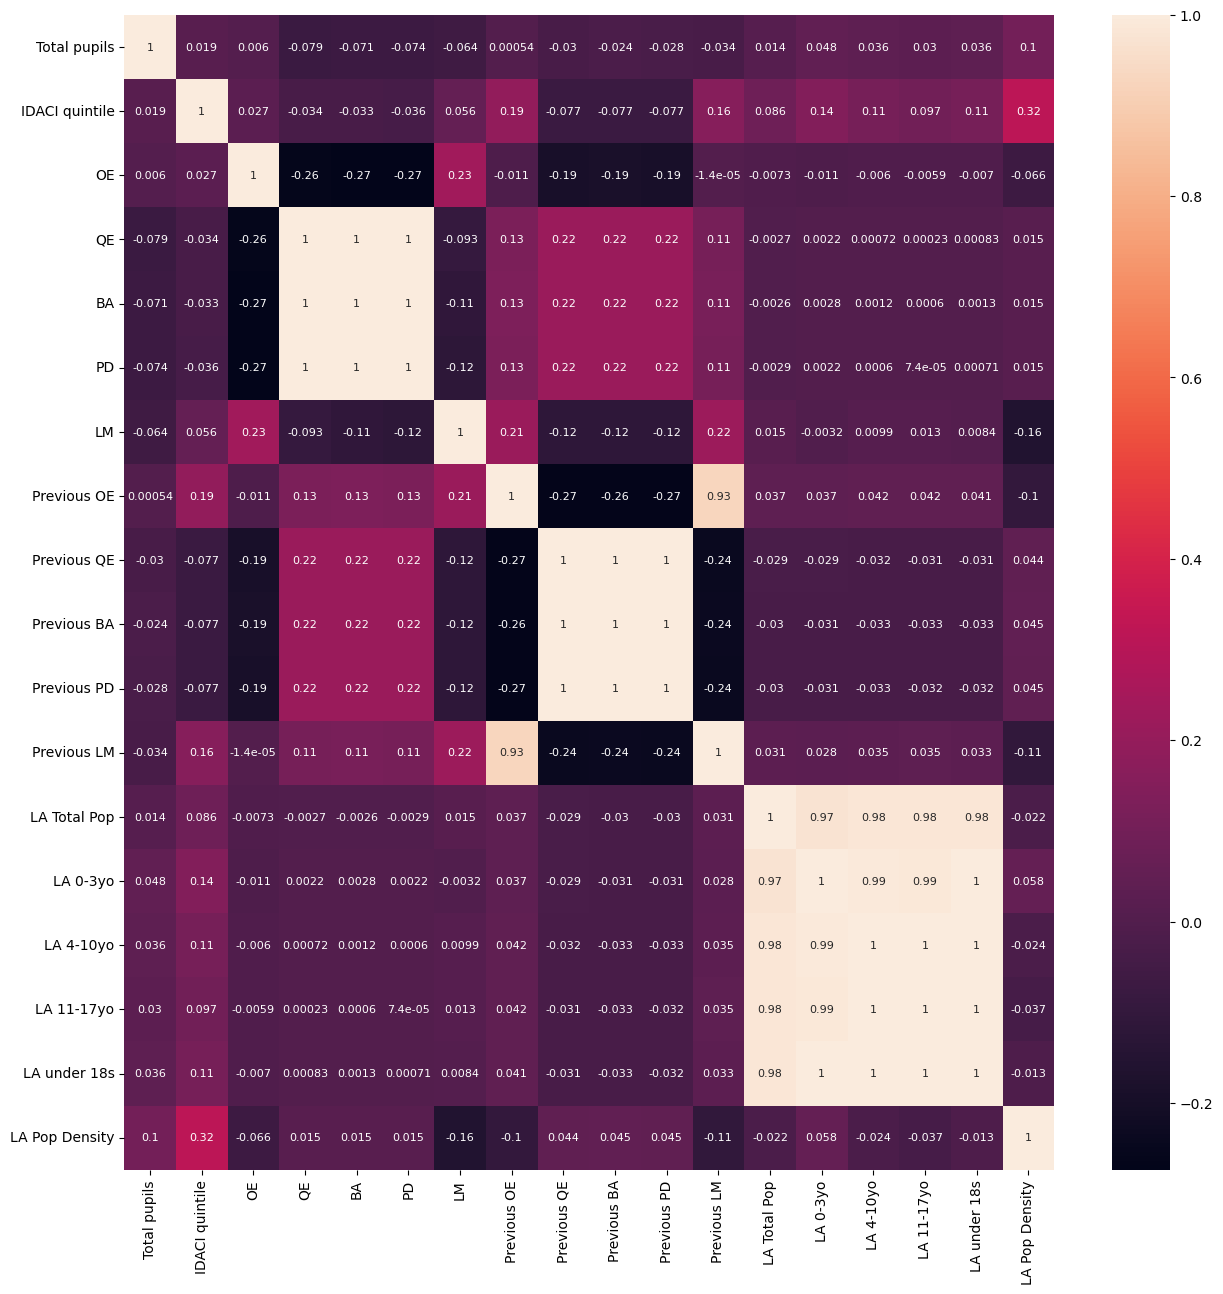

In [12]:
# Create correlation heatmap
sns.heatmap(sub.corr(), annot=True, ax=ax, annot_kws={"size": 8}, 
            xticklabels=1, yticklabels=1)
plt.show()

Comments:
- There is no significant correlation between most of the variables
- There is weak-to-moderate correlation (0.32) between population density in the local authority and the IDACI quintile.  This means that where more people live per square kilometre, the deprivation is higher.
- OE (overall effectiveness) is slightly negatively correlated with three of the other inspection judgements.  This seems strange, since overall effectiveness is, I thought, a summary of the other four judgements.  The correlation is weak, though.
- Overall effectiveness at the previous inspection is very strongly correlated (0.93) with the previous leadership and management score.  The correlation between these two variables is much weaker in the most recent inspections (0.23).  This is also unexpected.  Possibly there has been a change in the inspection framework in recent years.

### 3 Scatterplots

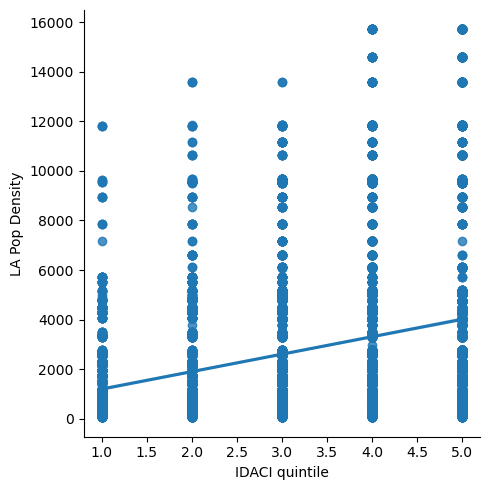

In [15]:
# Create a scatterplot for income deprivation and population density

sns.lmplot(x = 'IDACI quintile', y = 'LA Pop Density', data = df)
plt.show()

Comment:
The positive correlation is easiest to see at the higher end of the population density.  Local authorities with the highest population densities are concentrated at the higher end of the IDACI quintiles.  This shows that local authorities with the highest population densitites also have amongst the highest levels of deprivation in the population.

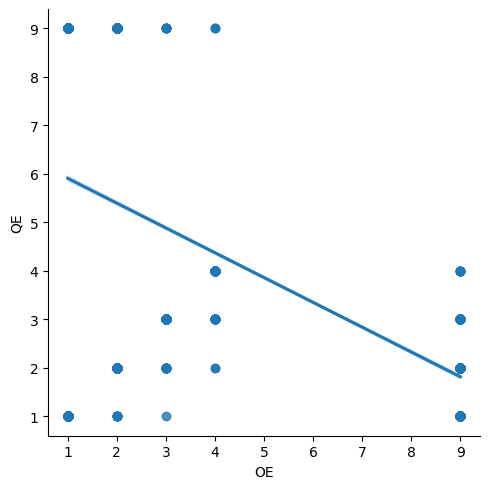

In [17]:
# Create a scatterplot for the inspection judgements "Overall Effectiveness" and "Quality of Education"

sns.lmplot(x = 'OE', y = 'QE', data = df)
plt.show()

Comments:
- Both these variables are not continuous data but ordinal
- 9 has been used to mean "no data" and these 9s are distorting the correlation drastically
- if we ignore the 9s, there is strong positive correlation
- OE (overall effectiveness) is sometimes higher than QE (quality of education), sometimes the same, but never lower

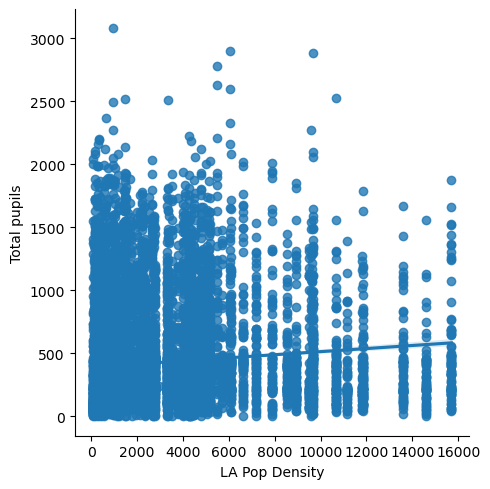

In [19]:
# Create a scatterplot for population density and total number of pupils in the school

sns.lmplot(x = 'LA Pop Density', y = 'Total pupils', data = df)
plt.show()

Comments:
- There is almost no correlation (0.1) here: very slight positive correlation
- The biggest schools are in areas of lower density.  In places with many villages, people travel to one school for the area.
- All regions of the country need small schools which cater for different needs, hence there is no correlation at the lower end.

### 4 Pair plot

In [22]:
g = sns.pairplot(df)

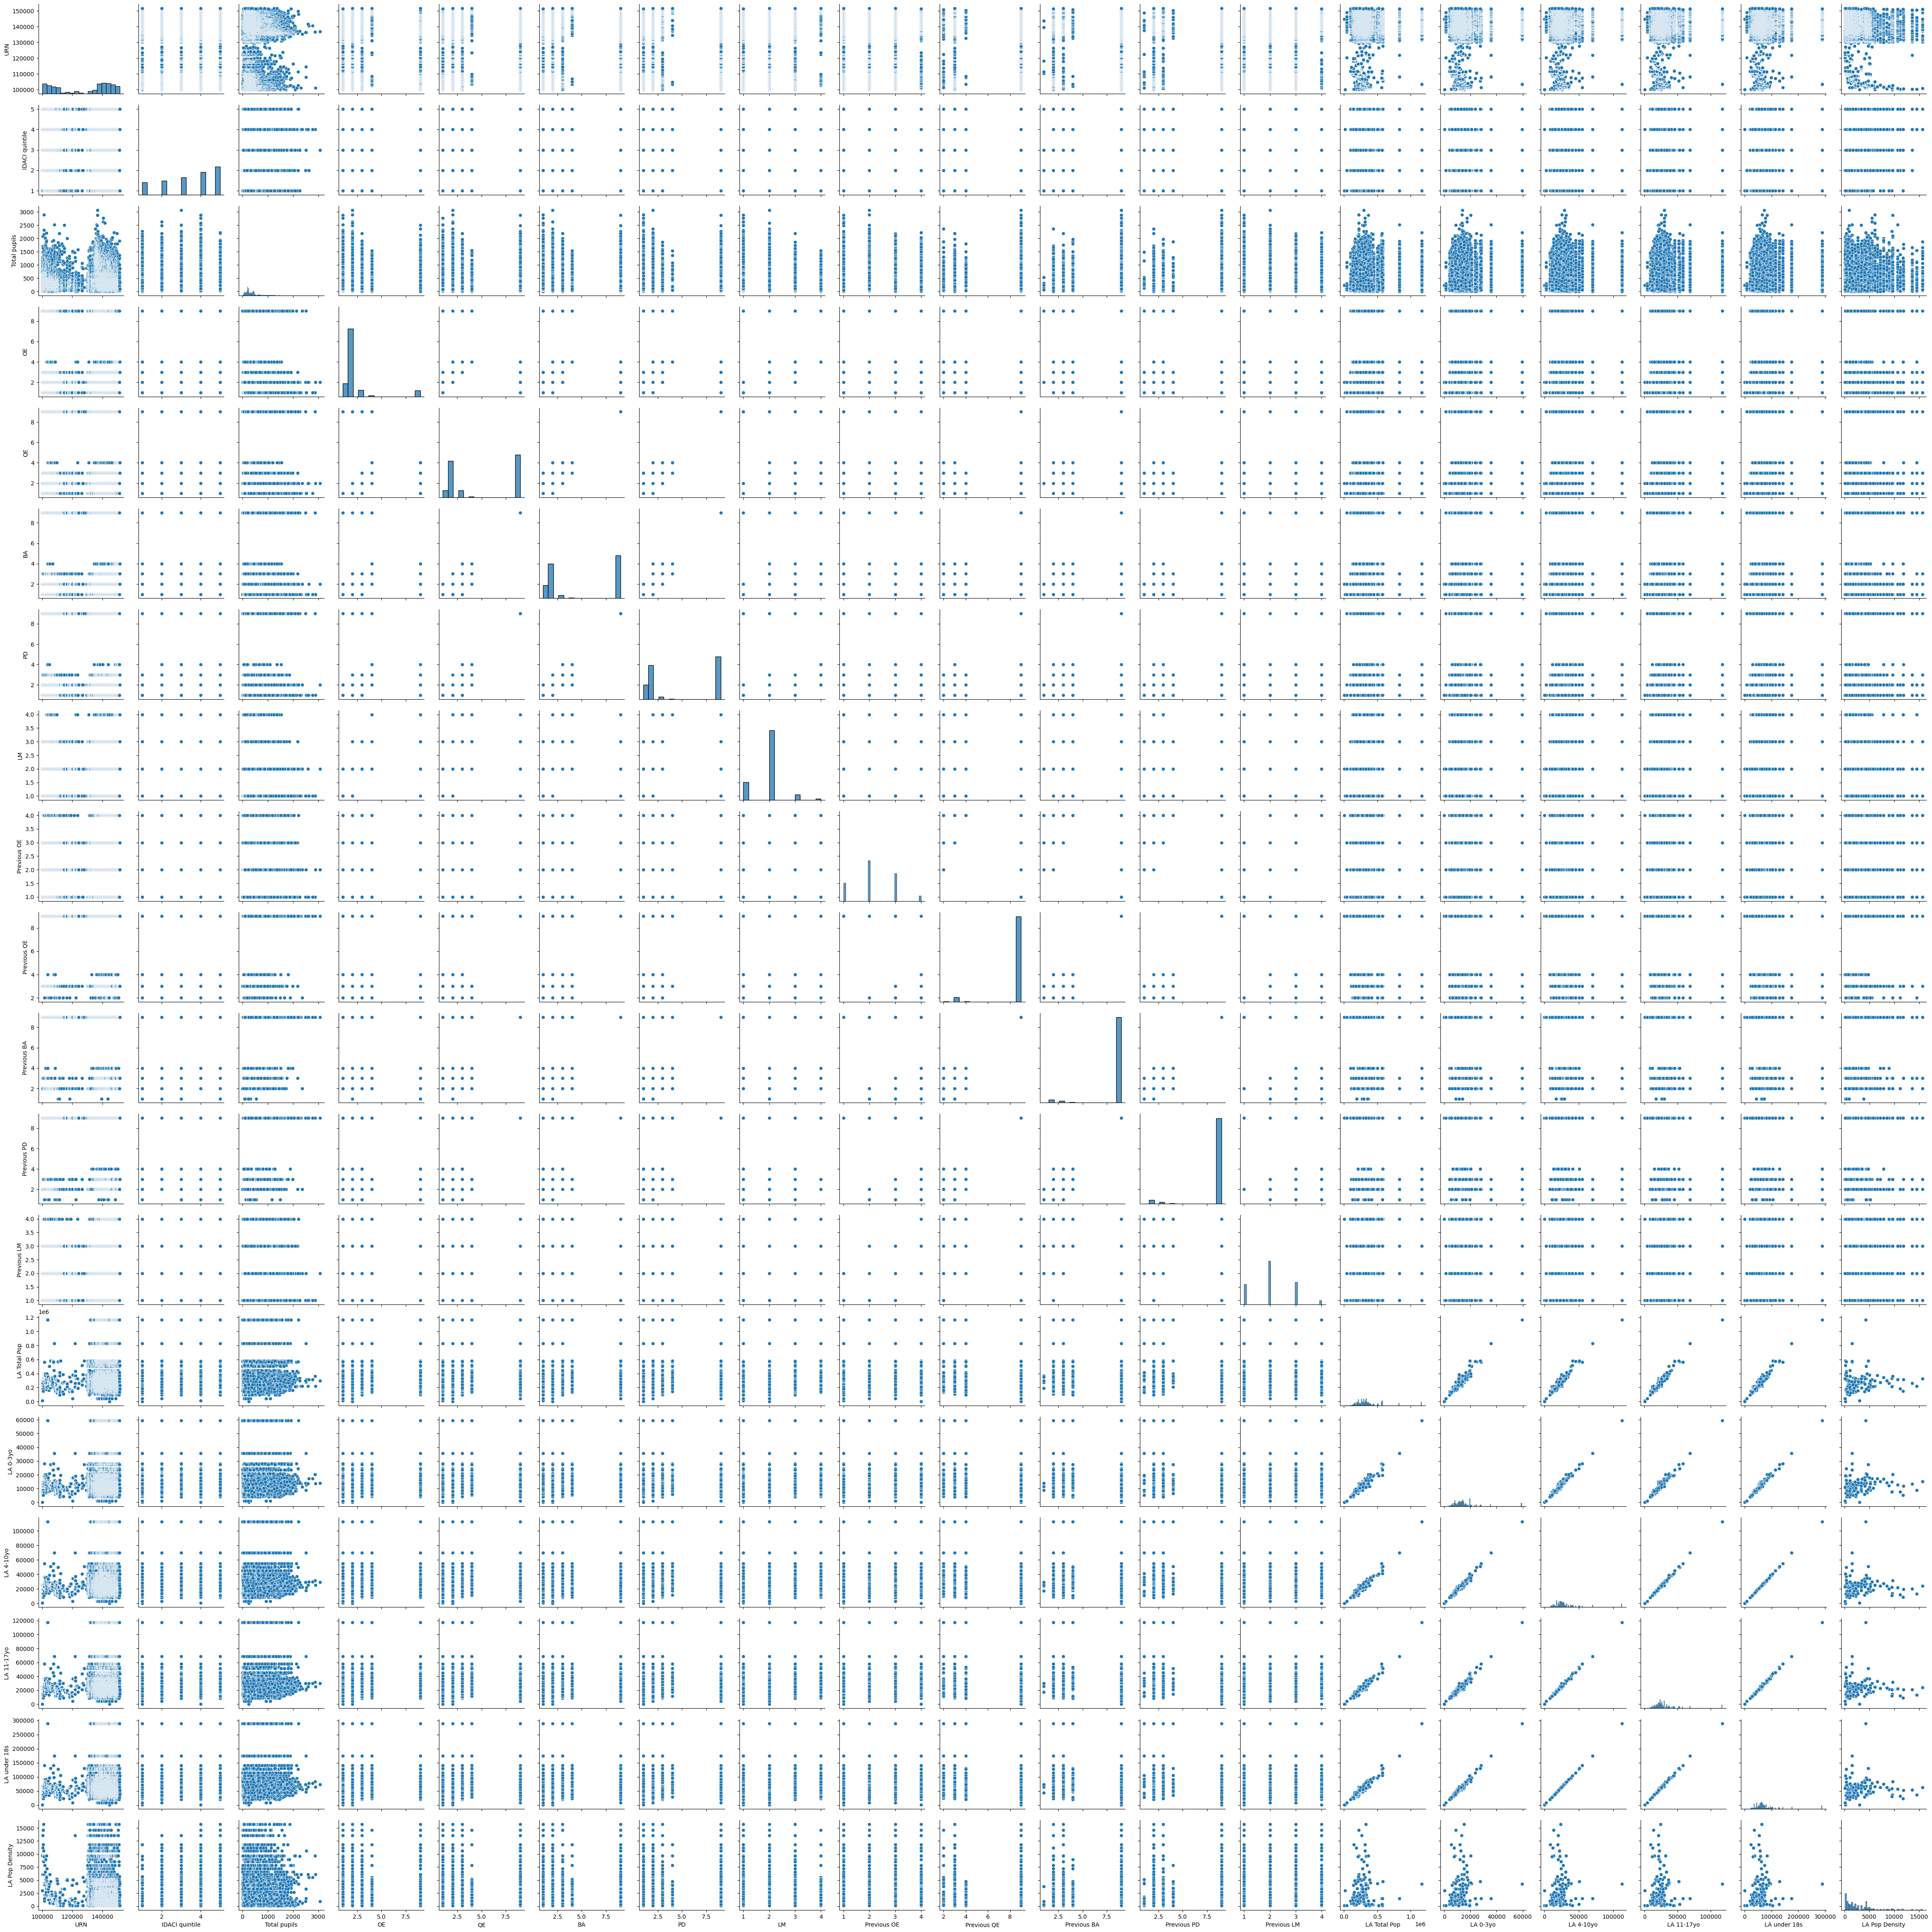

In [23]:
plt.show()

Comments:
- Looking at the various age categories in the local population reminds me that it would be interesting to group schools by phase and look for further patterns
- Why are lines forming at the top of the graphs with age categories on the y-axis?
- Previous QE, BA and PD are almost exclusively 9s, so they should be removed from further analysis

### 5 Categorical plot

In [26]:
df['Ofsted phase'].value_counts()

Ofsted phase
Primary      9020
Secondary    2033
Special       650
Nursery       251
PRU           190
Name: count, dtype: int64

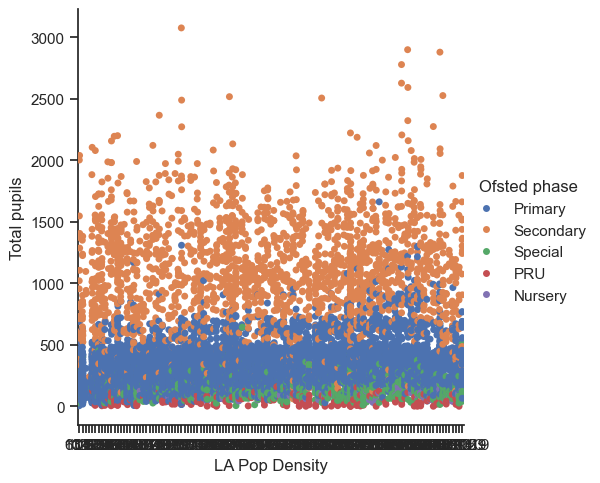

In [27]:
# Using Ofsted phase as category, create categorical plot of population density against number of pupils in school
sns.set(style="ticks")
g = sns.catplot(x="LA Pop Density", y="Total pupils", hue="Ofsted phase", data=df)
plt.show()

Comments:
- This catplot clearly shows that on the whole, secondary schools are larger than primary
- There might be weak positive correlation in the primary schools, with larger schools in more dense areas
- There appear to be more special schools in areas with higher population density
- PRUs, as expected, are the smallest schools and occur in all LAs

### 6 Revisiting questions from last task

#### Is inspection result related to size of school?

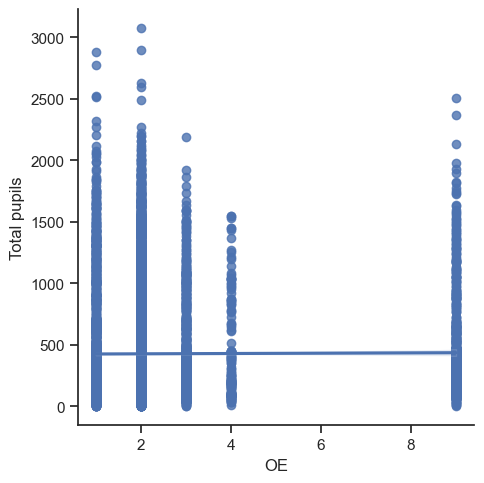

In [31]:
sns.lmplot(x = 'OE', y = 'Total pupils', data = df)
plt.show()

Answer:
- Yes!
- No school with more than 1600 pupils achieved the highest overall grade of 4.
- No school with more than 2300 pupils achieved higher than 2.

#### Do schools do better at one particular type of inspection outcome?

Answer:
- From the shapes of the distributions in the pairplots, it seems that QE has more 3s and fewer 1s than BA, PD and LM
- It would be interesting to look at summary statistics to explore this further

#### Does school size depend on population density in the local authority?

Answer:
- Yes!
- The correlation matrix and heatmap both showed that there is a very weak correlation of 0.1 between school size and population density in the local area
- The categorical plot showed further that this correlation may depend also on the Ofsted phase.

### 7 Hypotheses

1. There is no link between the previous inspection grading and the most recent inspection grading.
2. Schools who score above average in LM (leadership and management) tend to score below average in the other areas.

Hypothesis 1 is what is suggested by the relevant scatterplot in the pairplot, but it seems unexpected, so I would like to look further into this.  Hypothesis 2 arises from the heatmap, where the LM lines are different colours from the QE, BA, PD blocks (which are all the same colour as each other).